In [1]:
import shutil
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pyblock.blocking

from jaqmc.utils.config import ConfigManager

In [3]:
digest = dict(np.load("/rds/user/jc2405/hpc-work/JaQMC/jaqmc/runs/h_chain_3.78_2_h_3_supcell_i_0h_1s_j_3h_1s_rdm_eval_old/evaluation_digest.npz"))

print("Digest contents:")
for key, value in sorted(digest.items()):
    if value.ndim == 0:
        print(f"  {key}: {value:.6f}")
    else:
        print(f"  {key}: shape={value.shape}")

SiSj = 0.25*(digest['gamma2_uu_ijij'] + digest['gamma2_dd_ijij'] - digest['gamma2_ud_ijij'] - digest['gamma2_ud_jiji'])
print(f"<S_i S_j>: {SiSj}")
#j=3

Digest contents:
  energy:kinetic: 2.630739-0.000089j
  energy:kinetic_var: 5.398290-0.001225j
  energy:potential: -5.716905
  energy:potential_var: 5.395854
  gamma1_down_ii: 0.124922+0.000013j
  gamma1_up_ii: 0.123520+0.000011j
  gamma2_dd_ijij: 0.011476+0.000007j
  gamma2_ud_ijij: 0.019895+0.000018j
  gamma2_ud_jiji: 0.019179-0.000001j
  gamma2_uu_ijij: 0.012597-0.000023j
  total_energy: -3.086166-0.000089j
  total_energy_real: -3.086166
  total_energy_real_var: 0.001344
<S_i S_j>: (-0.003750187810510397-8.214944500650745e-06j)


In [ ]:
#Energy variance looks too big...? Probably need to run more iterations?

In [2]:
digest = dict(np.load("/rds/user/jc2405/hpc-work/JaQMC/jaqmc/runs/h_chain_rdm_i0j1_eval/evaluation_digest.npz"))

print("Digest contents:")
for key, value in sorted(digest.items()):
    if value.ndim == 0:
        print(f"  {key}: {value:.6f}")
    else:
        print(f"  {key}: shape={value.shape}")

SiSj = 0.25*(digest['gamma2_uu_ijij'] + digest['gamma2_dd_ijij'] - digest['gamma2_ud_ijij'] - digest['gamma2_ud_jiji'])
print(f"<S_i S_j>: {SiSj}")

Digest contents:
  energy:kinetic: 2.618067+0.000050j
  energy:kinetic_var: 5.342924-0.001221j
  energy:potential: -5.704156
  energy:potential_var: 5.341677
  gamma1_down_ii: 0.118549-0.000011j
  gamma1_up_ii: 0.127103+0.000025j
  gamma2_dd_ijij: 0.005207+0.000003j
  gamma2_ud_ijij: 0.021905-0.000003j
  gamma2_ud_jiji: 0.022341+0.000018j
  gamma2_uu_ijij: 0.005145-0.000006j
  total_energy: -3.086089+0.000050j
  total_energy_real: -3.086089
  total_energy_real_var: 0.001347
<S_i S_j>: (-0.008473464287817478-4.593907760863658e-06j)


Extracting <S_i S_j> values...

j = 1: <S_i S_j> = -0.008473-0.000005j
j = 2: <S_i S_j> = 0.002300-0.000005j
j = 3: <S_i S_j> = -0.003073-0.000012j
j = 4: <S_i S_j> = 0.003477-0.000001j
j = 5: <S_i S_j> = -0.007076-0.000002j

Shape check -> x: (7,), y: (7,)
Plot saved as 'SiSj_correlation.png'


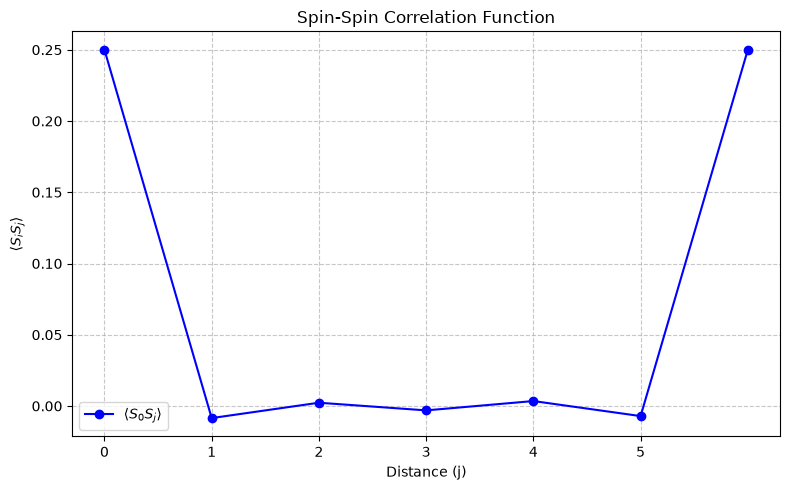

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Base directory where the run folders are stored
base_dir = "/rds/user/jc2405/hpc-work/JaQMC/jaqmc/runs"
j_values_run = np.arange(1, 6)  

# 1. Extract values into a completely new Python list
SiSj_list = []

print("Extracting <S_i S_j> values...\n")

for j in j_values_run:
    folder_name = f"h_chain_rdm_i0j{j}_eval"
    file_path = os.path.join(base_dir, folder_name, "evaluation_digest.npz")
    
    try:
        digest = dict(np.load(file_path))
        SiSj = 0.25 * (
            digest['gamma2_uu_ijij'] + 
            digest['gamma2_dd_ijij'] - 
            digest['gamma2_ud_ijij'] - 
            digest['gamma2_ud_jiji']
        )
        if isinstance(SiSj, np.ndarray) and SiSj.ndim == 0:
            SiSj = SiSj.item()
            
        SiSj_list.append(SiSj)
        print(f"j = {j}: <S_i S_j> = {SiSj:.6f}")
        
    except FileNotFoundError:
        print(f"Warning: File not found for j={j} at {file_path}")
        SiSj_list.append(np.nan)

# 2. Safely create the 7-element arrays
# Front: 0.25, Middle: the 5 extracted values, Back: 0.25 -> Total length = 7
SiSj_values = np.array([0.25] + SiSj_list + [0.25])
j_values_plot = np.array([0, 1, 2, 3, 4, 5, 6])

# Verify shapes match before plotting
print(f"\nShape check -> x: {j_values_plot.shape}, y: {SiSj_values.shape}")

# 3. Plotting the results
plt.figure(figsize=(8, 5))

plt.plot(j_values_plot, SiSj_values, marker='o', linestyle='-', color='b', label=r'$\langle S_0 S_j \rangle$')

plt.title('Spin-Spin Correlation Function')
plt.xlabel('Distance (j)')
plt.ylabel(r'$\langle S_i S_j \rangle$')

plt.xticks(np.arange(0, 6)) 
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.savefig("SiSj_correlation.png", dpi=300)
print("Plot saved as 'SiSj_correlation.png'")

plt.show()

Plot saved as 'SiSj_correlation.png'


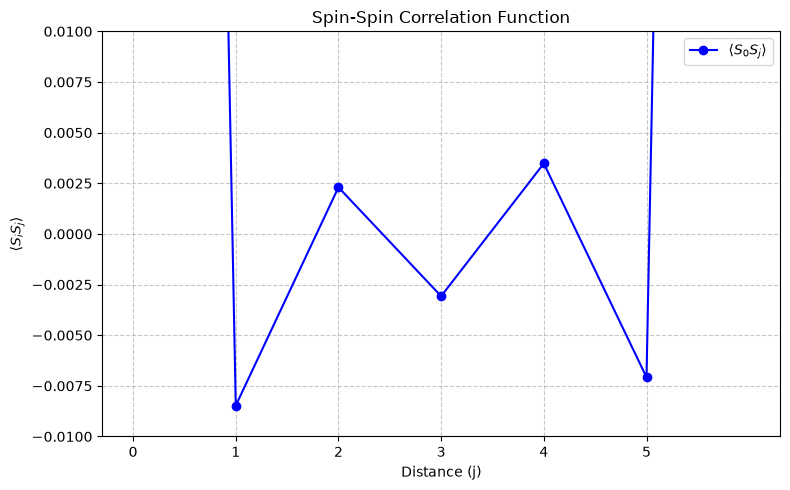

In [16]:
# 3. Plotting the results
plt.figure(figsize=(8, 5))

plt.plot(j_values_plot, SiSj_values, marker='o', linestyle='-', color='b', label=r'$\langle S_0 S_j \rangle$')

# ---------------------------------------------------------
# Set y-axis limits to +/- 0.01
# ---------------------------------------------------------
plt.ylim(-0.01, 0.01)

plt.title('Spin-Spin Correlation Function')
plt.xlabel('Distance (j)')
plt.ylabel(r'$\langle S_i S_j \rangle$')
plt.xticks(np.arange(0, 6)) 
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.savefig("SiSj_correlation.png", dpi=300)
print("Plot saved as 'SiSj_correlation.png'")

plt.show()